In [2]:
import numpy as np 
import pylab as plt 
import networkx as nx 
import pandas as pd 
from sklearn.manifold import MDS
from sklearn.metrics import pairwise_distances
from sklearn.decomposition import PCA

In [3]:
# Torus module imports 
from modules import geometry
from modules import graphio 
from modules import metrics 
from modules import visualization as vis
from modules.projector import MDSTorusProjector

## Lattice graph

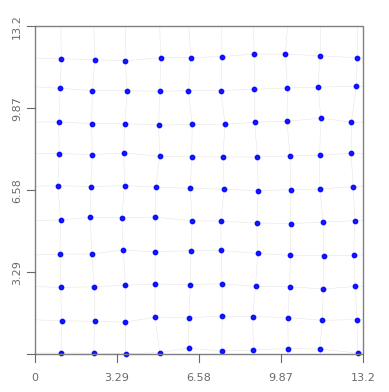

In [13]:
G,D = graphio.get_periodic_lattice(10,10)

#Normalize or don't
# D /= np.max(D)

proj_torus = MDSTorusProjector(random_state=45)
X_torus = proj_torus.fit_transform(D)

fig, ax = plt.subplots()

vis.plot_embedding_with_torus_edges(X_torus, G, ax=ax,torus=proj_torus)

fig.savefig("poster/grid-graph.pdf",dpi=200)

In [4]:
X_euc = MDS(dissimilarity="precomputed").fit_transform(D)

scaled_torus = lambda p, q: proj_torus.alpha_ * geometry.torus_distance(p, q)

stress     = ( metrics.geodesic_stress(X_torus,D, scaled_torus),    metrics.geodesic_stress(X_euc,D,geometry.euc_distance) )
distortion = ( metrics.geodesic_distortion(X_torus,D,scaled_torus), metrics.geodesic_distortion(X_euc,D,geometry.euc_distance) )
goodness   = ( metrics.SGS(X_torus,D,scaled_torus),                metrics.SGS(X_euc,D, geometry.euc_distance) )
NP         = ( metrics.geodesic_NP(X_torus,D,scaled_torus),        metrics.geodesic_NP(X_euc,D, geometry.euc_distance) )

df = pd.DataFrame({"name": ("torus", "Euclidean"), "stress": stress, "distortion": distortion, "goodness": goodness, "NP": NP})
df

,name,stress,distortion,goodness,NP
0,torus,0.10027,0.084853,0.962590,0.71686
1,Euclidean,0.31842,0.285590,0.679963,0.20000


## Grid cells

In [12]:
a = np.load("grid_cells_4800.npz")
data, spikes = metrics.subsample(5000, a['data'], a['spikes'])

D = pairwise_distances(data)

proj_torus = MDSTorusProjector()
X = proj_torus.fit_transform(D)

Text(0.5, 0.98, 'Firing rates of selected cells by spatial position\n Toroidal embedding')

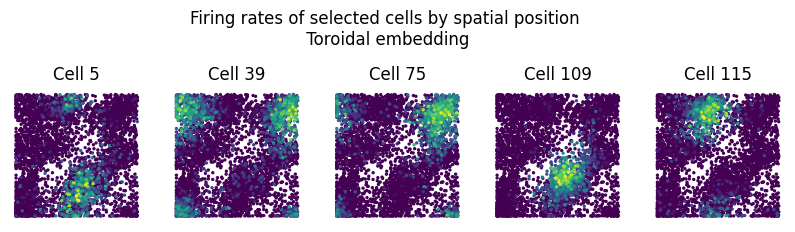

In [13]:
# spatial location of firing rates
fig, ax = plt.subplots(1, 5, figsize=(10, 3))

cell_ids = [5, 39, 75, 109, 115] # cells with clearly structured firing pattern

xx = X[:,0]
yy = X[:,1]
for i, idx in enumerate(cell_ids):
    order  = np.argsort(spikes[:, idx])  # to plot interesting time points on top
    ax[i].scatter(xx[order], yy[order], c=spikes[order, idx], s=2)
    ax[i].set_title(f"Cell {idx}")
    ax[i].axis("off")
    ax[i].set_aspect("equal")
fig.suptitle("Firing rates of selected cells by spatial position\n Toroidal embedding")

In [14]:
X_torus = X
#Since sklearn MDS is expensive, let it use the original coordinates
X_euc = MDS().fit_transform(data)

Text(0.5, 0.98, 'Firing rates of selected cells by spatial position\n Euclidean embedding')

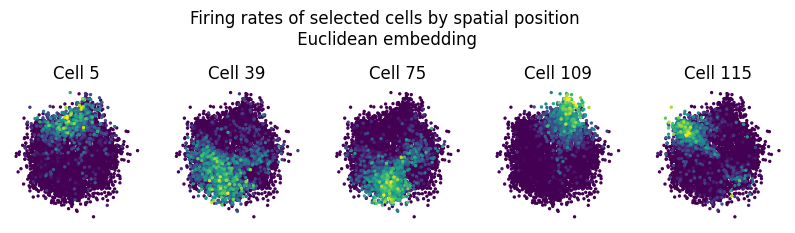

In [15]:
# spatial location of firing rates
fig, ax = plt.subplots(1, 5, figsize=(10, 3))

cell_ids = [5, 39, 75, 109, 115] # cells with clearly structured firing pattern

xx = X_euc[:,0]
yy = X_euc[:,1]
for i, idx in enumerate(cell_ids):
    order  = np.argsort(spikes[:, idx])  # to plot interesting time points on top
    ax[i].scatter(xx[order], yy[order], c=spikes[order, idx], s=2)
    ax[i].set_title(f"Cell {idx}")
    ax[i].axis("off")
    ax[i].set_aspect("equal")
fig.suptitle("Firing rates of selected cells by spatial position\n Euclidean embedding")

In [ ]:

scaled_torus = lambda p, q: proj_torus.alpha_ * geometry.torus_distance(p, q)

stress     = ( metrics.geodesic_stress(X_torus,D,scaled_torus),    metrics.geodesic_stress(X_euc,D,geometry.euc_distance) )
distortion = ( metrics.geodesic_distortion(X_torus,D,scaled_torus), metrics.geodesic_distortion(X_euc,D,geometry.euc_distance) )
goodness   = ( metrics.SGS(X_torus,D,scaled_torus),                metrics.SGS(X_euc,D,geometry.euc_distance) )
NP         = ( metrics.geodesic_NP(X_torus,D,scaled_torus),        metrics.geodesic_NP(X_euc,D,geometry.euc_distance) )

df = pd.DataFrame({"name": ("torus", "Euclidean"), "stress": stress, "distortion": distortion, "goodness": goodness, "NP": NP})
df

,name,stress,distortion,goodness,NP
0,torus,0.249734,0.206425,0.660601,0.151237
1,Euclidean,0.288088,0.238736,0.747538,0.157579


## Yoda and Bulldog

In [ ]:
pca = metrics.subsample(2000, np.load("yoda_bulldog_pca50.npy"))

D = pairwise_distances(pca[:,:10])
X = MDSTorusProjector().fit_transform(D)

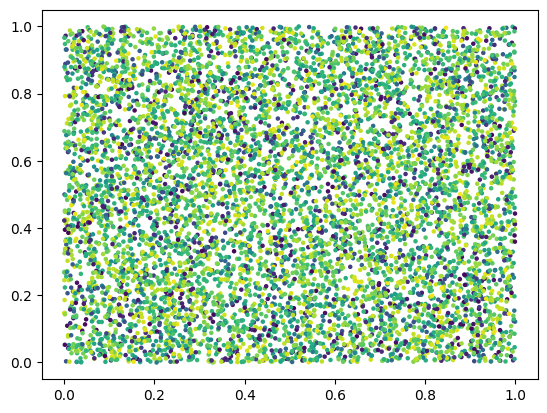

In [ ]:
fig, ax = plt.subplots()
plt.scatter(X[:,0], X[:,1],c=pca[:,3],s=5)

## Block models

In [14]:
G = nx.planted_partition_graph(5, 100, 0.2, 0.01)
# nx.nx_pydot.write_dot(G,"out.gv")
D, nodes = graphio.apsp_distance_matrix(G)

proj_torus = MDSTorusProjector()
X_torus = proj_torus.fit_transform(D)

<Axes: >

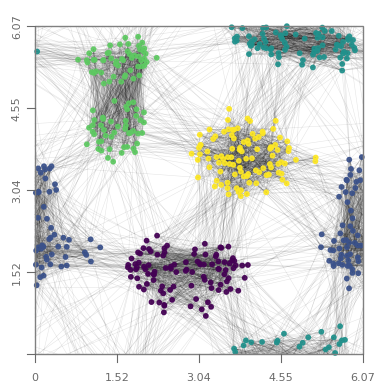

In [ ]:
colors = [0] * 100 + [1] * 100 + [2] * 100 + [3] * 100 + [4] * 100

fig, ax = plt.subplots()
vis.plot_embedding_with_torus_edges(X_torus, G, colors=colors,torus=proj_torus,ax=ax)

fig.savefig("poster/sbm.pdf", dpi=200)

In [23]:
X_euc = MDS(dissimilarity="precomputed").fit_transform(D)

scaled_torus = lambda p, q: proj_torus.alpha_ * geometry.torus_distance(p, q)

stress     = ( metrics.geodesic_stress(X_torus,D,scaled_torus),    metrics.geodesic_stress(X_euc,D,geometry.euc_distance) )
distortion = ( metrics.geodesic_distortion(X_torus,D,scaled_torus), metrics.geodesic_distortion(X_euc,D,geometry.euc_distance) )
goodness   = ( metrics.SGS(X_torus,D,scaled_torus),                metrics.SGS(X_euc,D,geometry.euc_distance) )
NP         = ( metrics.geodesic_NP(X_torus,D,scaled_torus),        metrics.geodesic_NP(X_euc,D,geometry.euc_distance) )

df = pd.DataFrame({"name": ("torus", "Euclidean"), "stress": stress, "distortion": distortion, "goodness": goodness, "NP": NP})
df

,name,stress,distortion,goodness,NP
0,torus,0.296901,0.243442,0.518981,0.545873
1,Euclidean,0.364499,0.310781,0.489481,0.515071


In [24]:
k = 7
partitions = [100] * k

G = nx.planted_partition_graph(k, 100, 0.2, 0.01)
D, nodes = graphio.apsp_distance_matrix(G)

proj_torus = MDSTorusProjector()
X_torus = proj_torus.fit_transform(D)

<Axes: >

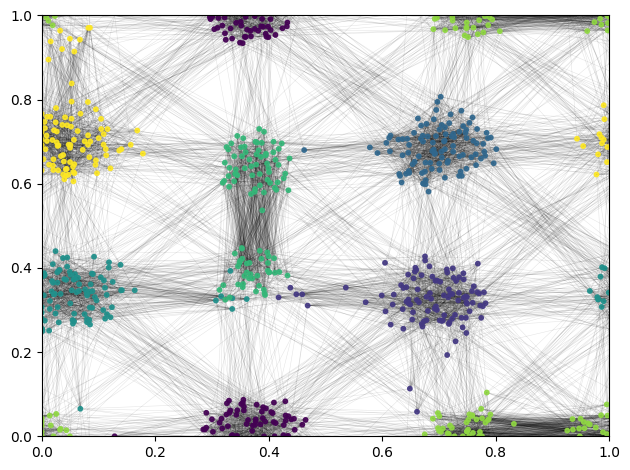

In [25]:
colors = np.array([[i] * 100 for i in range(k)], dtype=int).flatten()
vis.plot_embedding_with_torus_edges(X_torus, G, colors=list(colors))

In [26]:
X_euc = MDS(dissimilarity="precomputed").fit_transform(D)

scaled_torus = lambda p, q: proj_torus.alpha_ * geometry.torus_distance(p, q)

stress     = ( metrics.geodesic_stress(X_torus,D,scaled_torus),    metrics.geodesic_stress(X_euc,D,geometry.euc_distance) )
distortion = ( metrics.geodesic_distortion(X_torus,D,scaled_torus), metrics.geodesic_distortion(X_euc,D,geometry.euc_distance) )
goodness   = ( metrics.SGS(X_torus,D,scaled_torus),                metrics.SGS(X_euc,D,geometry.euc_distance) )
NP         = ( metrics.geodesic_NP(X_torus,D,scaled_torus),        metrics.geodesic_NP(X_euc,D,geometry.euc_distance) )

df = pd.DataFrame({"name": ("torus", "Euclidean"), "stress": stress, "distortion": distortion, "goodness": goodness, "NP": NP})
df

,name,stress,distortion,goodness,NP
0,torus,0.308184,0.251615,0.409295,0.466746
1,Euclidean,0.387289,0.328860,0.381928,0.434456


## TODO 
** check if learned scale is close to optimal **
** Try rat brain data on the rhombic torus ** 